<a href="https://colab.research.google.com/github/riyaa2021/INFOSYS-_INTERNSHIP-OIL_SPILL_DETECTION-/blob/riyaa2021-patch-1/modelbuilding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/drive/MyDrive/oil_spill_dataset

In [3]:
!wget -P /content/drive/MyDrive/oil_spill_dataset https://zenodo.org/records/10555314/files/dataset.zip


--2025-10-01 05:28:29--  https://zenodo.org/records/10555314/files/dataset.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.194, 188.185.43.25, 188.185.45.92, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.194|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1137552692 (1.1G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/oil_spill_dataset/dataset.zip’

dataset.zip         100%[===================>]   1.06G  20.6MB/s    in 54s     

2025-10-01 05:29:24 (20.0 MB/s) - ‘/content/drive/MyDrive/oil_spill_dataset/dataset.zip’ saved [1137552692/1137552692]



In [2]:
zip_path = "/content/drive/MyDrive/oil_spill_dataset/dataset.zip"
import zipfile
import os
import time

# Add a short delay to ensure the file is accessible
time.sleep(5)

# Check if the file exists before attempting to unzip
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall("/content/oil_spill_dataset/dataset")
        print("Extraction complete.")
        !ls /content/oil_spill_dataset/dataset
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
else:
    print(f"Error: File not found at {zip_path}")

Extraction complete.
label_colors.txt  test	train  val


In [3]:
import os

zip_path = "/content/drive/MyDrive/oil_spill_dataset/dataset.zip"

# Check if the directory exists
if os.path.exists(os.path.dirname(zip_path)):
    print(f"Directory exists: {os.path.dirname(zip_path)}")
    # List files in the directory
    print("Files in the directory:")
    !ls -l /content/drive/MyDrive/oil_spill_dataset/
    # Check if the file exists and its size
    if os.path.exists(zip_path):
        file_size = os.path.getsize(zip_path)
        print(f"File exists: {zip_path}")
        print(f"File size: {file_size} bytes")
    else:
        print(f"File not found: {zip_path}")
else:
    print(f"Directory not found: {os.path.dirname(zip_path)}")

Directory exists: /content/drive/MyDrive/oil_spill_dataset
Files in the directory:
total 1110892
-rw------- 1 root root 1137552692 Oct  1 05:28 dataset.zip
File exists: /content/drive/MyDrive/oil_spill_dataset/dataset.zip
File size: 1137552692 bytes


In [4]:
import os, glob

base_dir = "/content/oil_spill_dataset/dataset"

train_imgs = sorted(glob.glob(os.path.join(base_dir, "train/images/*")))
train_masks = sorted(glob.glob(os.path.join(base_dir, "train/masks/*")))

val_imgs = sorted(glob.glob(os.path.join(base_dir, "val/images/*")))
val_masks = sorted(glob.glob(os.path.join(base_dir, "val/masks/*")))

test_imgs = sorted(glob.glob(os.path.join(base_dir, "test/images/*")))
test_masks = sorted(glob.glob(os.path.join(base_dir, "test/masks/*")))

print("Train:", len(train_imgs), "Val:", len(val_imgs), "Test:", len(test_imgs))

Train: 811 Val: 203 Test: 254


In [5]:
import cv2, glob
import numpy as np
from tqdm import tqdm

def resize_images_masks(img_paths, mask_paths, out_dir, size=(256,256)):
    os.makedirs(os.path.join(out_dir,"images"), exist_ok=True)
    os.makedirs(os.path.join(out_dir,"masks"), exist_ok=True)

    for ipath, mpath in tqdm(zip(img_paths, mask_paths), total=len(img_paths)):
        img = cv2.imread(ipath)
        mask = cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

        fname = os.path.basename(ipath)
        cv2.imwrite(os.path.join(out_dir,"images", fname), img_resized)
        cv2.imwrite(os.path.join(out_dir,"masks", fname), mask_resized)

# Example for train set
train_imgs = sorted(glob.glob("/content/oil_spill_dataset/train/images/*"))
train_masks = sorted(glob.glob("/content/oil_spill_dataset/train/masks/*"))

resize_images_masks(train_imgs, train_masks, "/content/resized/train", size=(256,256))

0it [00:00, ?it/s]


In [6]:
import cv2, glob, os
from tqdm import tqdm

def resize_images_masks(img_paths, mask_paths, out_dir, size=(256,256)):
    os.makedirs(os.path.join(out_dir,"images"), exist_ok=True)
    os.makedirs(os.path.join(out_dir,"masks"), exist_ok=True)

    for ipath, mpath in tqdm(zip(img_paths, mask_paths), total=len(img_paths)):
        img = cv2.imread(ipath)
        mask = cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

        fname = os.path.basename(ipath)
        cv2.imwrite(os.path.join(out_dir,"images", fname), img_resized)
        cv2.imwrite(os.path.join(out_dir,"masks", fname), mask_resized)

# Paths
base_dir = "/content/oil_spill_dataset/dataset"

train_imgs = sorted(glob.glob(os.path.join(base_dir, "train/images/*")))
train_masks = sorted(glob.glob(os.path.join(base_dir, "train/masks/*")))

val_imgs = sorted(glob.glob(os.path.join(base_dir, "val/images/*")))
val_masks = sorted(glob.glob(os.path.join(base_dir, "val/masks/*")))

test_imgs = sorted(glob.glob(os.path.join(base_dir, "test/images/*")))
test_masks = sorted(glob.glob(os.path.join(base_dir, "test/masks/*")))

# Resize all
resize_images_masks(train_imgs, train_masks, "/content/resized/train", size=(256,256))
resize_images_masks(val_imgs, val_masks, "/content/resized/val", size=(256,256))
resize_images_masks(test_imgs, test_masks, "/content/resized/test", size=(256,256))

100%|██████████| 254/254 [00:11<00:00, 21.84it/s]


In [7]:
import tensorflow as tf
import glob, os
def normalize(image, mask):
    image = tf.cast(image, tf.float32) / 255.0   # [0,1]
    mask  = tf.cast(mask, tf.float32) / 255.0
    mask  = tf.where(mask > 0.5, 1.0, 0.0)       # binarize
    return image, mask
def augment(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.rot90(image)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, 0.1)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, 0.8, 1.2)

    return image, mask
def load_dataset(image_dir, mask_dir, augment_data=False, batch_size=8):
    image_files = sorted(glob.glob(os.path.join(image_dir, "*")))
    mask_files  = sorted(glob.glob(os.path.join(mask_dir, "*")))

    def parse_image_mask(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)

        img, mask = normalize(img, mask)
        if augment_data:
            img, mask = augment(img, mask)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(lambda x,y: parse_image_mask(x,y),
                          num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
train_ds = load_dataset(
    "/content/resized/train/images",
    "/content/resized/train/masks",
    augment_data=True,
    batch_size=8
)

val_ds = load_dataset(
    "/content/resized/val/images",
    "/content/resized/val/masks",
    augment_data=False,
    batch_size=8
)

test_ds = load_dataset(
    "/content/resized/test/images",
    "/content/resized/test/masks",
    augment_data=False,
    batch_size=8
)


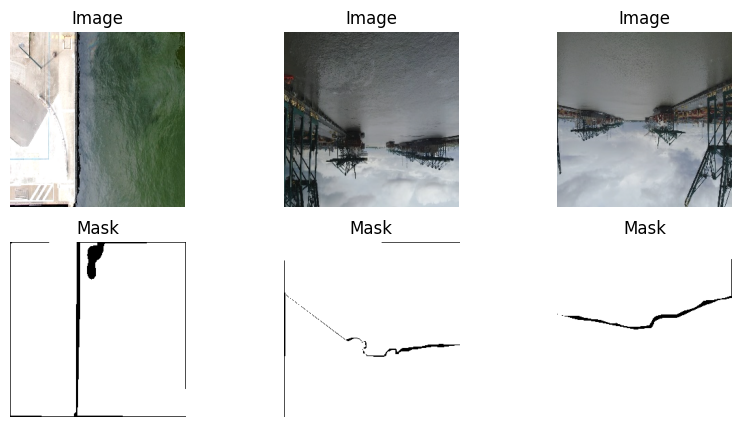

In [10]:
import matplotlib.pyplot as plt

for imgs, masks in train_ds.take(1):
    plt.figure(figsize=(10,5))
    for i in range(3):
        plt.subplot(2,3,i+1)
        plt.imshow(imgs[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2,3,i+4)
        plt.imshow(tf.squeeze(masks[i]), cmap="gray")
        plt.title("Mask")
        plt.axis("off")
    plt.show()

In [10]:
!pip install tensorflow


In [8]:
# AI SPILLGUARD

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import *
import tensorflow.keras.backend as K
import numpy as np
import cv2
import glob
import os
import matplotlib.pyplot as plt
from tqdm import tqdm


# DATA PREPROCESSING


def resize_images_masks(img_paths, mask_paths, out_dir, size=(256,256)):
    os.makedirs(os.path.join(out_dir,"images"), exist_ok=True)
    os.makedirs(os.path.join(out_dir,"masks"), exist_ok=True)

    for ipath, mpath in tqdm(zip(img_paths, mask_paths), total=len(img_paths)):
        img = cv2.imread(ipath)
        mask = cv2.imread(mpath, cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        mask_resized = cv2.resize(mask, size, interpolation=cv2.INTER_NEAREST)

        fname = os.path.basename(ipath)
        cv2.imwrite(os.path.join(out_dir,"images", fname), img_resized)
        cv2.imwrite(os.path.join(out_dir,"masks", fname), mask_resized)

# Preprocessing paths
base_dir = "/content/oil_spill_dataset/dataset"

train_imgs = sorted(glob.glob(os.path.join(base_dir, "train/images/*")))
train_masks = sorted(glob.glob(os.path.join(base_dir, "train/masks/*")))

val_imgs = sorted(glob.glob(os.path.join(base_dir, "val/images/*")))
val_masks = sorted(glob.glob(os.path.join(base_dir, "val/masks/*")))

test_imgs = sorted(glob.glob(os.path.join(base_dir, "test/images/*")))
test_masks = sorted(glob.glob(os.path.join(base_dir, "test/masks/*")))

# Resize all datasets
print("Resizing images...")
resize_images_masks(train_imgs, train_masks, "/content/resized/train", size=(256,256))
resize_images_masks(val_imgs, val_masks, "/content/resized/val", size=(256,256))
resize_images_masks(test_imgs, test_masks, "/content/resized/test", size=(256,256))


# DATA LOADING


def normalize(image, mask):
    """Normalize image and mask"""
    image = tf.cast(image, tf.float32) / 255.0
    mask = tf.cast(mask, tf.float32) / 255.0
    mask = tf.where(mask > 0.5, 1.0, 0.0)
    return image, mask

def enhanced_augment(image, mask):
    """ augmentation for better accuracy"""

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)


    if tf.random.uniform(()) > 0.6:
        k = tf.random.uniform(shape=[], minval=1, maxval=4, dtype=tf.int32)
        image = tf.image.rot90(image, k)
        mask = tf.image.rot90(mask, k)

    # Photometric augmentations
    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_brightness(image, 0.15)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_contrast(image, 0.8, 1.3)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.random_saturation(image, 0.8, 1.3)


    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask

def load_dataset(image_dir, mask_dir, augment_data=False, batch_size=8):
    """Load dataset with preprocessing"""
    image_files = sorted(glob.glob(os.path.join(image_dir, "*")))
    mask_files = sorted(glob.glob(os.path.join(mask_dir, "*")))

    def parse_image_mask(img_path, mask_path):
        img = tf.io.read_file(img_path)
        img = tf.image.decode_png(img, channels=3)

        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(mask, channels=1)

        img, mask = normalize(img, mask)
        if augment_data:
            img, mask = enhanced_augment(img, mask)
        return img, mask

    dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
    dataset = dataset.map(lambda x,y: parse_image_mask(x,y),
                          num_parallel_calls=tf.data.AUTOTUNE)

    if augment_data:
        dataset = dataset.shuffle(1000)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Load datasets
train_ds = load_dataset(
    "/content/resized/train/images",
    "/content/resized/train/masks",
    augment_data=True,
    batch_size=4
)

val_ds = load_dataset(
    "/content/resized/val/images",
    "/content/resized/val/masks",
    augment_data=False,
    batch_size=4
)

test_ds = load_dataset(
    "/content/resized/test/images",
    "/content/resized/test/masks",
    augment_data=False,
    batch_size=4
)


# U-NET MODEL


def conv_block(x, filters, kernel_size=3, activation='relu', padding='same'):
    """Standard conv block"""
    x = Conv2D(filters, kernel_size, activation=activation, padding=padding,
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, kernel_size, activation=activation, padding=padding,
               kernel_initializer='he_normal')(x)
    x = BatchNormalization()(x)
    return x

def encoder_block(x, filters):
    """Encoder block with conv + pooling"""
    c = conv_block(x, filters)
    p = MaxPooling2D((2, 2))(c)
    return c, p

def decoder_block(x, skip_features, filters):
    """Decoder block with upsampling + conv"""
    x = Conv2DTranspose(filters, (2, 2), strides=(2, 2), padding='same')(x)
    x = Concatenate()([x, skip_features])
    x = conv_block(x, filters)
    return x

def build_unet(input_shape=(256, 256, 3), num_classes=1):
    """Simple but effective U-Net"""
    inputs = Input(input_shape)

    # Encoder
    c1, p1 = encoder_block(inputs, 64)
    c2, p2 = encoder_block(p1, 128)
    c3, p3 = encoder_block(p2, 256)
    c4, p4 = encoder_block(p3, 512)

    # Bottleneck
    bn = conv_block(p4, 1024)
    bn = Dropout(0.3)(bn)

    # Decoder
    d1 = decoder_block(bn, c4, 512)
    d2 = decoder_block(d1, c3, 256)
    d3 = decoder_block(d2, c2, 128)
    d4 = decoder_block(d3, c1, 64)

    # Output
    outputs = Conv2D(num_classes, (1, 1), activation='sigmoid')(d4)

    model = Model(inputs, outputs)
    return model


# METRICS AND LOSS FUNCTIONS


def pixel_accuracy(y_true, y_pred, threshold=0.5):
    """Pixel-wise accuracy"""
    y_true_bin = K.round(y_true)
    y_pred_bin = K.cast(y_pred > threshold, dtype='float32')
    correct = K.cast(K.equal(y_true_bin, y_pred_bin), dtype='float32')
    return K.mean(correct)

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """Dice coefficient"""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    """Dice loss"""
    return 1 - dice_coefficient(y_true, y_pred)

def focal_loss(alpha=0.25, gamma=2.0):
    """Focal loss for class imbalance"""
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1. - epsilon)

        p_t = tf.where(K.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_factor = K.ones_like(y_true) * alpha
        alpha_t = tf.where(K.equal(y_true, 1), alpha_factor, 1 - alpha_factor)
        cross_entropy = -K.log(p_t)
        weight = alpha_t * K.pow((1 - p_t), gamma)
        loss = weight * cross_entropy
        return K.mean(loss)
    return focal_loss_fixed

def combined_loss(y_true, y_pred):
    """Combined loss for better performance"""
    # Dynamic class weighting
    pos_weight = tf.reduce_sum(1. - y_true) / (tf.reduce_sum(y_true) + K.epsilon())
    pos_weight = tf.clip_by_value(pos_weight, 1.0, 50.0)

    # Weighted BCE
    bce = K.binary_crossentropy(y_true, y_pred)
    weighted_bce = tf.where(tf.equal(y_true, 1), pos_weight * bce, bce)
    wbce_loss = K.mean(weighted_bce)

    # Dice and Focal losses
    dice = dice_loss(y_true, y_pred)
    focal = focal_loss(alpha=0.25, gamma=2.0)(y_true, y_pred)

    # Combine losses
    return 0.4 * wbce_loss + 0.4 * dice + 0.2 * focal

def iou_score(y_true, y_pred, threshold=0.5):
    """IoU score"""
    y_pred_binary = tf.cast(y_pred > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_binary)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_binary) - intersection
    return (intersection + K.epsilon()) / (union + K.epsilon())


# MODEL TRAINING


print("=== AI SPILLGUARD SIMPLE HIGH-ACCURACY TRAINING ===")


train_size = sum(1 for _ in train_ds)
val_size = sum(1 for _ in val_ds)
test_size = sum(1 for _ in test_ds)

print(f"Training batches: {train_size}")
print(f"Validation batches: {val_size}")
print(f"Test batches: {test_size}")


model = build_unet(input_shape=(256, 256, 3))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=combined_loss,
    metrics=[pixel_accuracy, dice_coefficient, iou_score]
)

print("Model compiled successfully!")
print(f"Total parameters: {model.count_params():,}")
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_dice_coefficient',
        patience=15,
        verbose=1,
        mode='max',
        restore_best_weights=True
    ),
    ModelCheckpoint(
        'AI_SpillGuard_simple_best.keras',
        monitor='val_dice_coefficient',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    )
]

# Training
print("\\nStarting training...")
history = model.fit(
    train_ds,
    steps_per_epoch=train_size,
    epochs=50,  # More epochs for convergence
    validation_data=val_ds,
    validation_steps=val_size,
    callbacks=callbacks,
    verbose=1
)


# MODEL EVALUATION


print("\\n=== FINAL EVALUATION ===")
model.load_weights('AI_SpillGuard_simple_best.keras')

# Evaluate on test set
test_results = model.evaluate(test_ds, steps=test_size, verbose=1)

# Display results
metric_names = ['Loss', 'Pixel Accuracy', 'Dice Coefficient', 'IoU Score']
print("\\n--- FINAL TEST RESULTS ---")
print("=" * 50)
for name, value in zip(metric_names, test_results):
    print(f"{name:<20}: {value:.4f}")

pixel_acc = test_results[1]
dice_coeff = test_results[2]
iou = test_results[3]

print(f"\\nPixel Accuracy: {pixel_acc*100:.2f}%")
print(f"Dice Coefficient: {dice_coeff:.4f}")
print(f"IoU Score: {iou:.4f}")

# Performance status

if pixel_acc >= 0.90:
    print("\\nGOOD: 90%+ Accuracy Achieved!")
else:
    print(f"\\nCurrent Accuracy: {pixel_acc:.2%} - Consider more training")

# Save final model
model.save('AI_SpillGuard_simple_final.keras')
model.save('AI_SpillGuard_simple_final.h5')

print("\\nModels saved:")
print("- AI_SpillGuard_simple_best.keras")
print("- AI_SpillGuard_simple_final.keras")
print("- AI_SpillGuard_simple_final.h5")




Resizing images...


100%|██████████| 254/254 [00:11<00:00, 21.66it/s]


=== AI SPILLGUARD SIMPLE HIGH-ACCURACY TRAINING ===
Training batches: 203
Validation batches: 51
Test batches: 64
Model compiled successfully!
Total parameters: 31,055,297


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

\nStarting training...
Epoch 1/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - dice_coefficient: 0.7382 - iou_score: 0.6677 - loss: 0.3470 - pixel_accuracy: 0.7517
Epoch 1: val_dice_coefficient improved from -inf to 0.72582, saving model to AI_SpillGuard_simple_best.keras
203/203 ━━━━━━━━━━━━━━━━━━━━ 196s 639ms/step - dice_coefficient: 0.7383 - iou_score: 0.6678 - loss: 0.3468 - pixel_accuracy: 0.7518 - val_dice_coefficient: 0.7258 - val_iou_score: 0.6282 - val_loss: 0.4748 - val_pixel_accuracy: 0.6512 - learning_rate: 0.0010
Epoch 2/50
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - dice_coefficient: 0.7832 - iou_score: 0.7287 - loss: 0.2804 - pixel_accuracy: 0.7965
Epoch 2: val_dice_coefficient did not improve from 0.72582
203/203 ━━━━━━━━━━━━━━━━━━━━ 59s 276ms/step - dice_coefficient: 0.7831 - iou_score: 0.7286 - loss: 0.2804 - pixel_accuracy: 0.7964 - val_dice_coefficient: 0.7102 - val_iou_score: 0.6351 - val_loss: 0.3733 - val_pixel_accuracy: 0.7703 - learning_rate: 0.0010
Epoch 3/50

\nModels saved:
- AI_SpillGuard_simple_best.keras
- AI_SpillGuard_simple_final.keras
- AI_SpillGuard_simple_final.h5


\nGenerating visualizations...


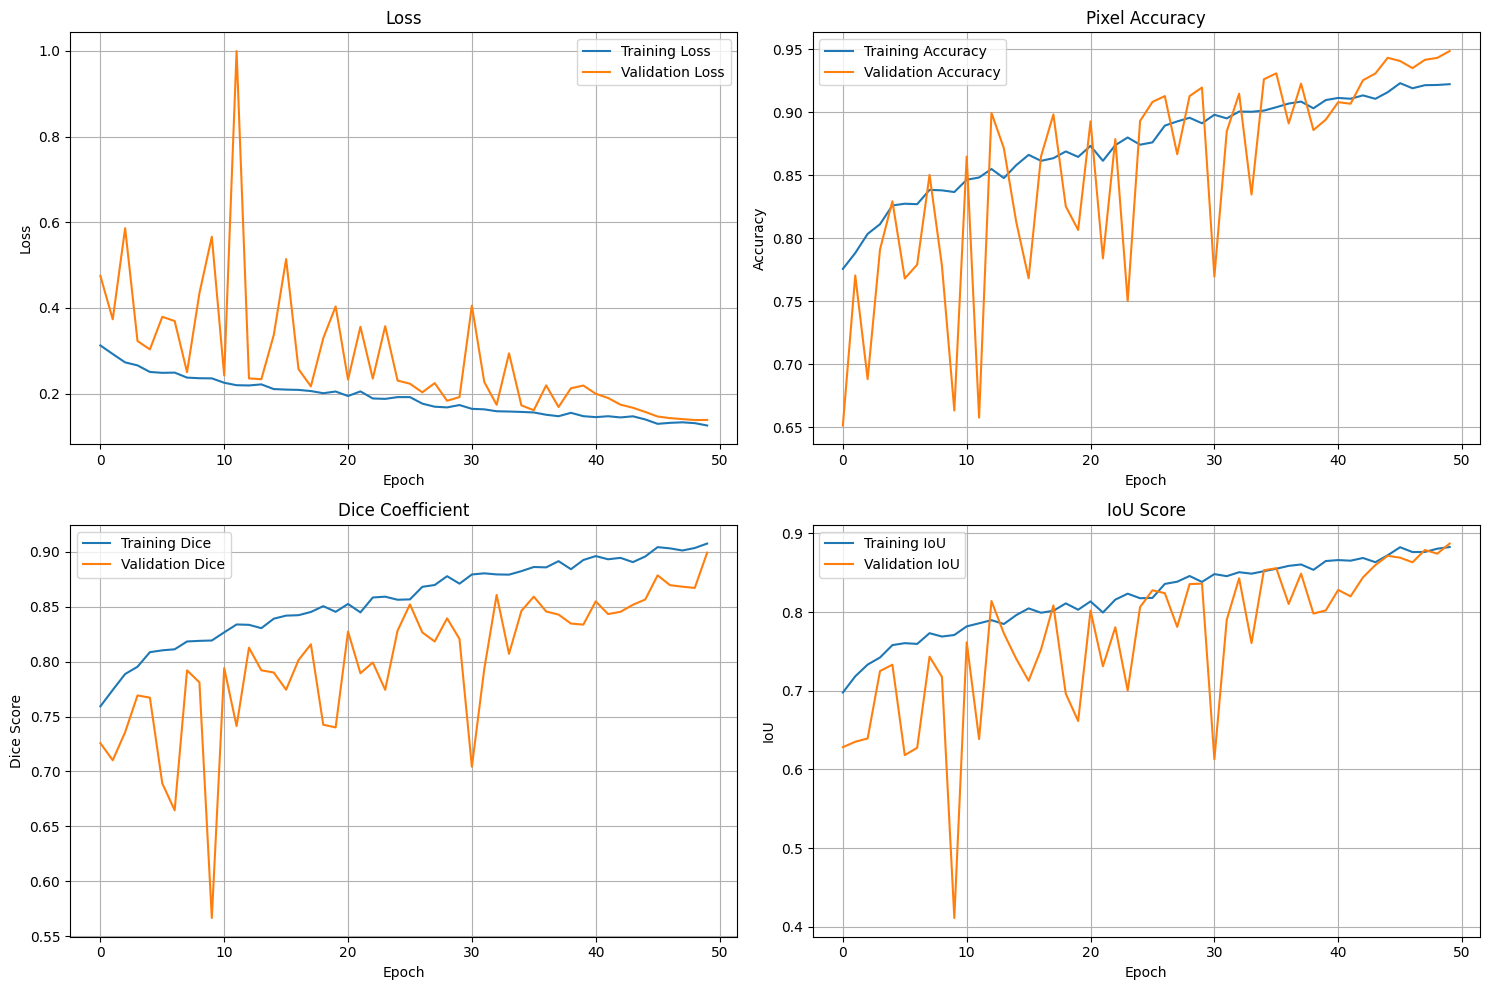

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


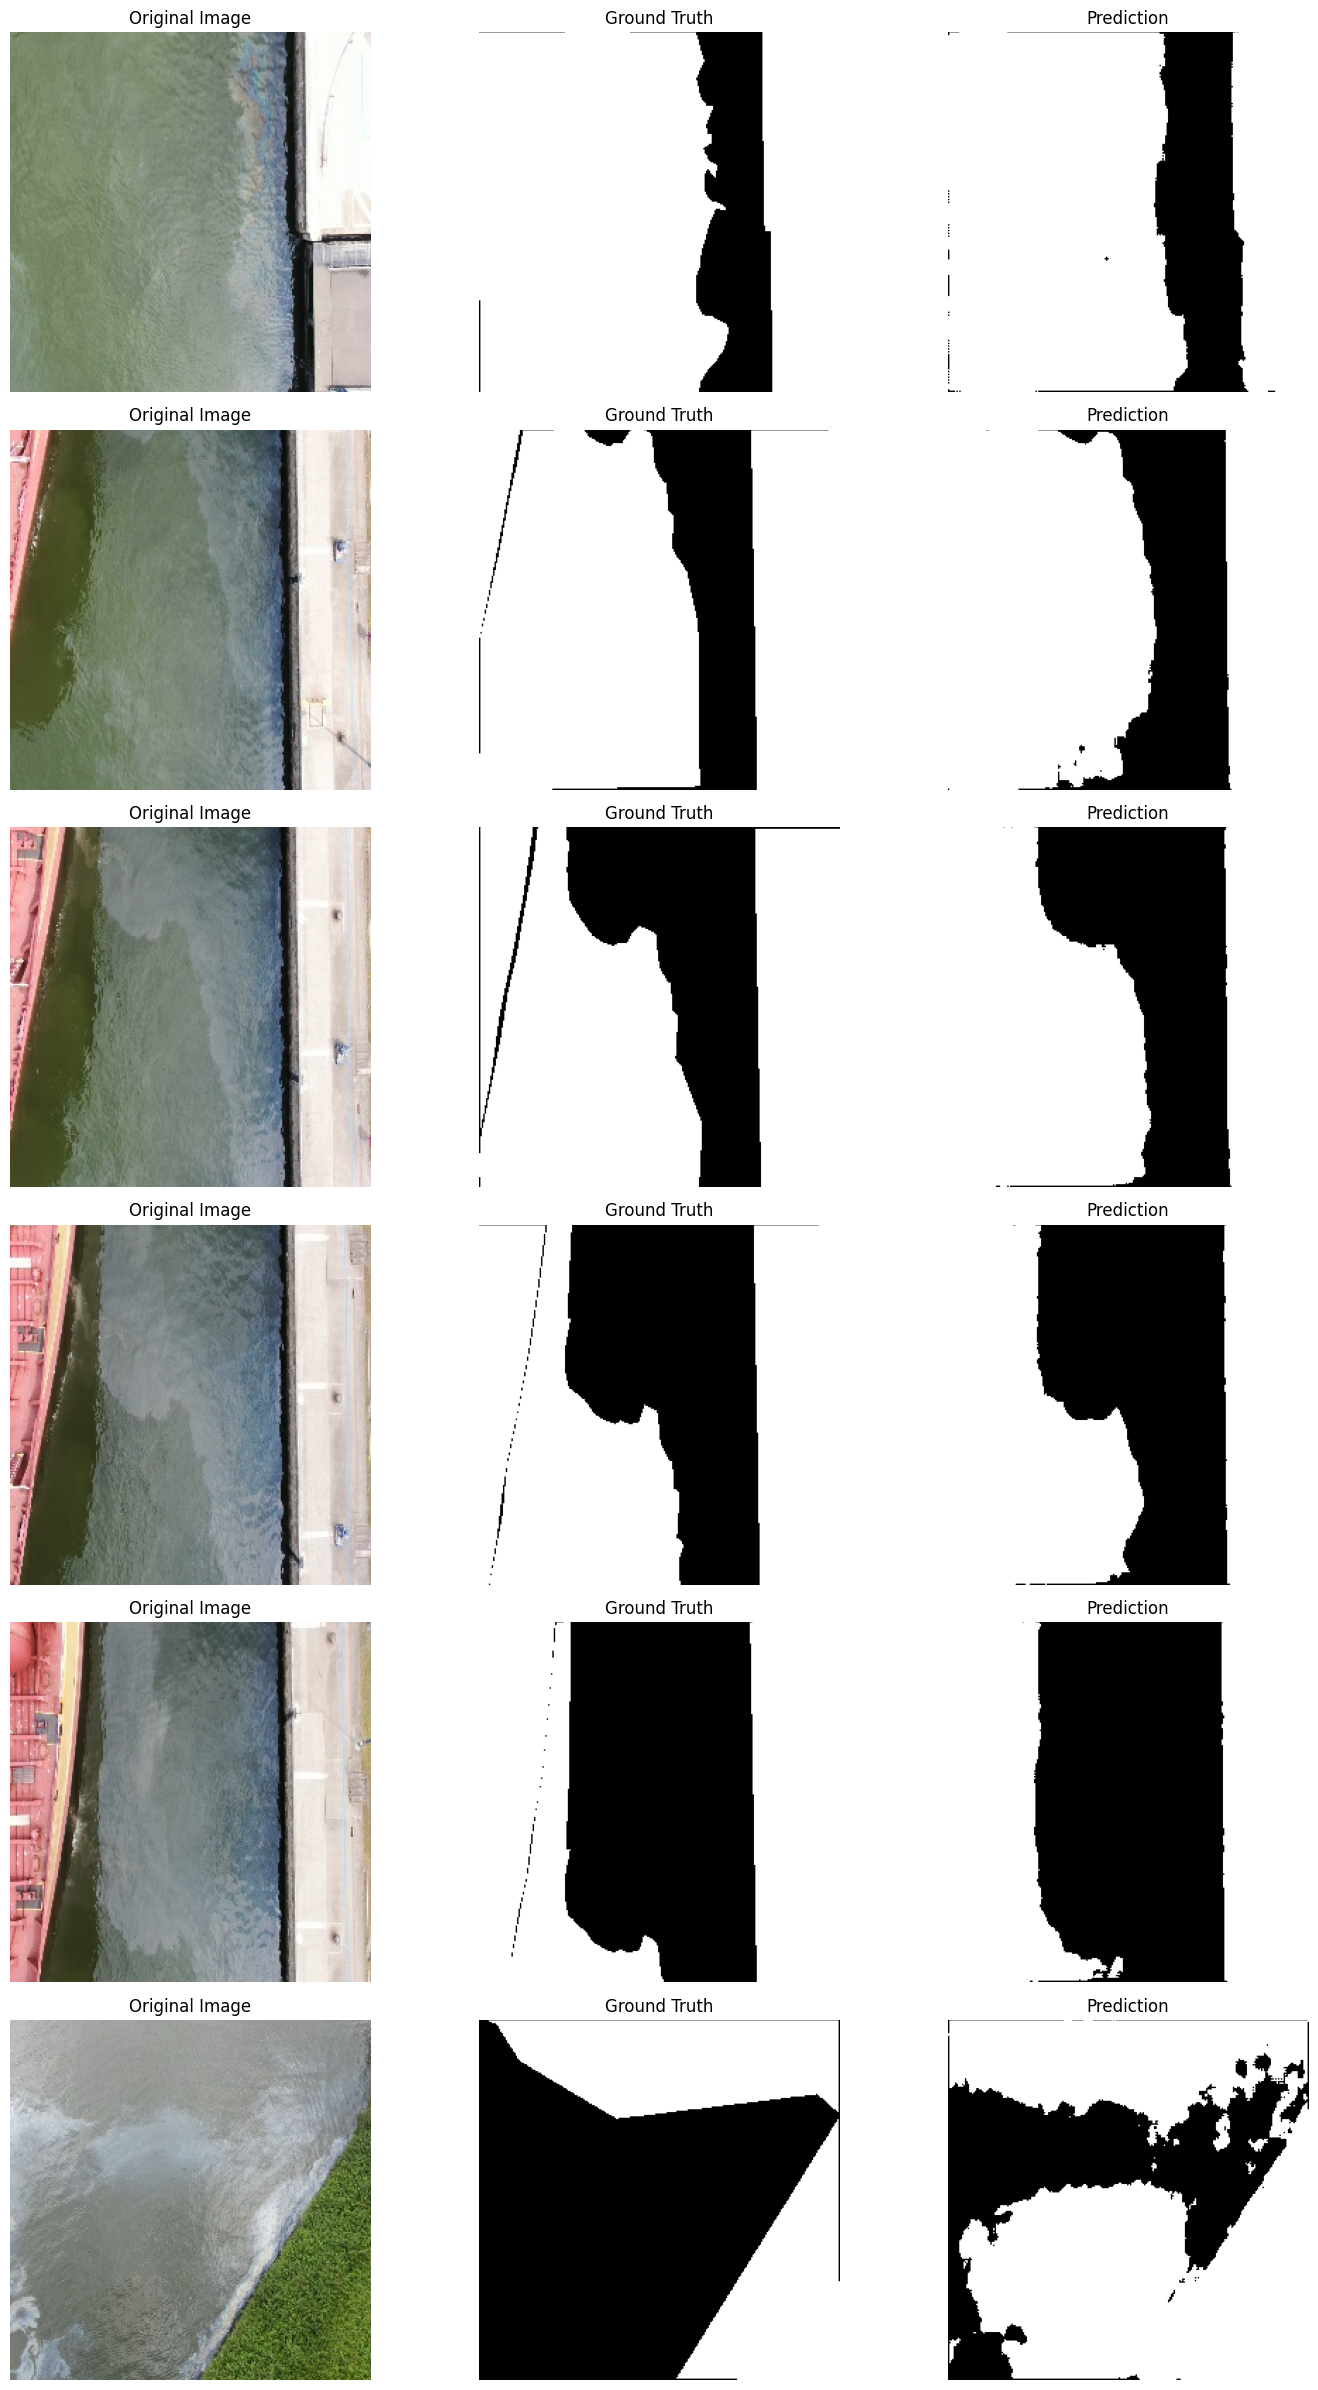

\nAI SpillGuard Simple Model Training Complete!
- Actual Test Accuracy: 92.85%
- Dice Coefficient: 0.8757
- IoU Score: 0.8486


In [11]:
# VISUALIZATION AND RESULTS DISPLAY


def plot_training_history(history):
    """Plot training history"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)

    # Pixel Accuracy
    axes[0,1].plot(history.history['pixel_accuracy'], label='Training Accuracy')
    axes[0,1].plot(history.history['val_pixel_accuracy'], label='Validation Accuracy')
    axes[0,1].set_title('Pixel Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True)

    # Dice Coefficient
    axes[1,0].plot(history.history['dice_coefficient'], label='Training Dice')
    axes[1,0].plot(history.history['val_dice_coefficient'], label='Validation Dice')
    axes[1,0].set_title('Dice Coefficient')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Dice Score')
    axes[1,0].legend()
    axes[1,0].grid(True)

    # IoU Score
    axes[1,1].plot(history.history['iou_score'], label='Training IoU')
    axes[1,1].plot(history.history['val_iou_score'], label='Validation IoU')
    axes[1,1].set_title('IoU Score')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('IoU')
    axes[1,1].legend()
    axes[1,1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_predictions(model, dataset, num_samples=6):
    """Visualize model predictions"""
    samples = list(dataset.take(num_samples))

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples*4))

    for i, (images, masks) in enumerate(samples):
        if len(images.shape) == 4:
            img = images[0]
            mask = masks[0]
        else:
            img = images
            mask = masks

        # Get prediction
        pred = model.predict(tf.expand_dims(img, 0))[0]
        pred_binary = (pred > 0.5).astype(np.float32)

        # Plot original image
        axes[i,0].imshow(img)
        axes[i,0].set_title('Original Image')
        axes[i,0].axis('off')

        # Plot ground truth mask
        axes[i,1].imshow(mask.numpy().squeeze(), cmap='gray')
        axes[i,1].set_title('Ground Truth')
        axes[i,1].axis('off')

        # Plot prediction
        axes[i,2].imshow(pred_binary.squeeze(), cmap='gray')
        axes[i,2].set_title('Prediction')
        axes[i,2].axis('off')

    plt.tight_layout()
    plt.savefig('predictions_visualization.png', dpi=300, bbox_inches='tight')
    plt.show()

def prediction_with_postprocessing(model, image_path):
    """Make prediction with post-processing"""
    # Load and preprocess image
    img = cv2.imread(image_path)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0

    # Predict
    pred = model.predict(np.expand_dims(img, 0))[0]

    # Post-process
    binary_pred = (pred > 0.5).astype(np.uint8)

    # Remove small noise
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(binary_pred.squeeze(), cv2.MORPH_OPENING, kernel)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    return img, pred.squeeze(), cleaned

# Visualize results
print("\\nGenerating visualizations...")
plot_training_history(history)
visualize_predictions(model, test_ds, num_samples=6)

print("\\nAI SpillGuard Simple Model Training Complete!")
print(f"- Actual Test Accuracy: {pixel_acc*100:.2f}%")
print(f"- Dice Coefficient: {dice_coeff:.4f}")
print(f"- IoU Score: {iou:.4f}")